In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer
from transformers import TFAutoModel
from arabert.preprocess import ArabertPreprocessor

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [11]:
from symbolicModel import (
    build_symbolic_matrix,
    learn_rule_confidence,
    RULE_CONFIDENCE,
    symbolic_detector,
    show_symbolic_result
)

In [12]:
ModelName = "aubmindlab/bert-large-arabertv02"

MAX_LEN = 120
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [13]:
train_df = pd.read_csv(
    "/Users/roamsaleh/Downloads/similedata/cleaned_train.csv"
)

val_df = pd.read_csv(
    "/Users/roamsaleh/Downloads/similedata/cleaned_validation.csv"
)

test_df = pd.read_csv(
    "/Users/roamsaleh/Downloads/similedata/cleaned_test.csv"
)

In [14]:
X_train = train_df["text"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label"].tolist()

print(len(X_train), len(X_val), len(X_test))

6000 1108 3000


In [15]:
learned_scores = learn_rule_confidence(
    X_train,
    y_train
)

# update symbolic confidence dynamically
RULE_CONFIDENCE.update(learned_scores)

print("\nLearned Rule Confidence:")
print(RULE_CONFIDENCE)


Learned Rule Confidence:
{'explicit_particle': 0.9, 'weak_particle': 0.983, 'verb_simile': 0.927, 'nominal_simile': 0.985, 'prefix_simile': 0.676}


In [16]:
X_train_sym = build_symbolic_matrix(X_train)

X_val_sym = build_symbolic_matrix(X_val)

X_test_sym = build_symbolic_matrix(X_test)
print("\nSymbolic Feature Shapes:")
print(X_train_sym.shape, X_val_sym.shape, X_test_sym.shape)


Symbolic Feature Shapes:
(6000, 11) (1108, 11) (3000, 11)


In [17]:
arabert_prep = ArabertPreprocessor(
    model_name=ModelName
)

tokenizer = AutoTokenizer.from_pretrained(
    ModelName
)

In [18]:
def PreprocessTexts(texts):

    texts = [
        arabert_prep.preprocess(text)
        for text in texts
    ]

    encodings = tokenizer(

        texts,

        max_length=MAX_LEN,

        padding='max_length',

        truncation=True,

        return_tensors='tf'
    )

    return (
        encodings['input_ids'],
        encodings['attention_mask']
    )

In [19]:
X_train_ids, X_train_mask = PreprocessTexts(
    X_train
)

X_val_ids, X_val_mask = PreprocessTexts(
    X_val
)

X_test_ids, X_test_mask = PreprocessTexts(
    X_test
)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [67]:
class HybridAraBERT(tf.keras.Model):
 
    def __init__(self, model_name, alpha=0.7):
        super().__init__()
 
        # ── AraBERT backbone 
        self.arabert = TFAutoModel.from_pretrained(
            model_name,
            from_pt=True
        )
 
        self.alpha = alpha
 
        # ── Neural classifier head 
        self.dense1 = tf.keras.layers.Dense(
            256,
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(0.01)
        )
 
        self.dropout = tf.keras.layers.Dropout(0.5)
 
        self.dense2 = tf.keras.layers.Dense(
            64,
            activation='relu'
        )
 
        self.bert_out = tf.keras.layers.Dense(
            1,
            activation='sigmoid',
            name="bert_probability"
        )
 
        # ── Symbolic sub-network (all 11 features) ────
        # Feature map:
        #   0  has_structure        6  has_verb
        #   1  num_structures       7  has_noun
        #   2  max_conf             8  has_prefix
        #   3  avg_conf             9  avg_distance
        #   4  has_strong_particle  10 multi_simile_flag
        #   5  has_weak_particle
 
        self.sym_dense = tf.keras.layers.Dense(
            16,
            activation='relu',
            name="sym_hidden"
        )
 
        self.sym_out = tf.keras.layers.Dense(
            1,
            activation='sigmoid',
            name="sym_score"
        )
 
    def _forward(self, inputs, training=False):
        """
        Shared forward pass.
        Returns (final_output, bert_prob).
        """
 
        input_ids, attention_mask, sym_input = inputs
 
        # ── AraBERT (keyword args avoid dict-tracing bug) ──
        outputs = self.arabert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            training=training,
            return_dict=False
        )[0]
 
        # CLS token — encodes full sentence meaning
        cls = outputs[:, 0, :]
 
        # ── Neural head 
        x         = self.dense1(cls)
        x         = self.dropout(x, training=training)
        x         = self.dense2(x)
        bert_prob = self.bert_out(x)
 
        # ── Symbolic sub-network (all 11 features) ────
        sym_hidden     = self.sym_dense(sym_input)
        symbolic_score = self.sym_out(sym_hidden)
 
        # ── Hybrid fusion 
        final_output = (
            self.alpha * bert_prob +
            (1 - self.alpha) * symbolic_score
        )
 
        return final_output, bert_prob
 
    def call(self, inputs, training=False):
        """
        Returns only final_output.
        Keras 3 requires a single tensor from call()
        during training.
        """
        final_output, _ = self._forward(
            inputs,
            training=training
        )
        return final_output
 
    def predict_both(self, inputs):
        """
        Returns (final_output, bert_prob).
        Use this for evaluation and explainability.
        """
        return self._forward(inputs, training=False)

In [68]:
model = HybridAraBERT(ModelName, alpha=0.7)
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
 
# Warm-up: builds all weights before summary
_ = model(
    [X_train_ids[:1], X_train_mask[:1], X_train_sym[:1]],
    training=False
)
 
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'bert.embeddings.position_ids', 'cls.predictions.decoder.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the 

Model: "hybrid_ara_bert_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (1, 256)               │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (1, 64)                │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bert_probability (Dense)        │ (1, 1)                 │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sym_hidden (Dense)              │ (1, 16)                │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sym_score (Dense)               │ (1, 1)                 │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,122 (1.06 MB)

 Trainable params: 279,122 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [70]:
history = model.fit(
 
    [X_train_ids, X_train_mask, X_train_sym],
 
    np.array(y_train),
 
    validation_data=(
        [X_val_ids, X_val_mask, X_val_sym],
        np.array(y_val)
    ),
 
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1172s 3s/step - accuracy: 0.4997 - loss: 4.7816 - val_accuracy: 0.5253 - val_loss: 4.6271
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1072s 3s/step - accuracy: 0.5293 - loss: 4.5806 - val_accuracy: 0.5731 - val_loss: 4.4520
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1067s 3s/step - accuracy: 0.5480 - loss: 4.4179 - val_accuracy: 0.6200 - val_loss: 4.2842
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1072s 3s/step - accuracy: 0.5513 - loss: 4.2524 - val_accuracy: 0.6444 - val_loss: 4.1241
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1080s 3s/step - accuracy: 0.5897 - loss: 4.0877 - val_accuracy: 0.6769 - val_loss: 3.9713
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1074s 3s/step - accuracy: 0.5990 - loss: 3.9404 - val_accuracy: 0.6922 - val_loss: 3.8242
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1074s 3s/step - accuracy: 0.6172 - loss: 3.7944 - val_accuracy: 0.7058 - val_loss: 3.6812
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1079s 3s/step - accuracy: 0.6170 - loss: 3.6639 - 

In [73]:
y_val_pred_prob, bert_val_prob = model.predict_both(
    [X_val_ids, X_val_mask, X_val_sym]
)
 
y_val_pred = (y_val_pred_prob.numpy() > 0.5).astype(int)


In [74]:

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
 
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))


Validation Confusion Matrix:
[[408 138]
 [153 409]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       546
           1       0.75      0.73      0.74       562

    accuracy                           0.74      1108
   macro avg       0.74      0.74      0.74      1108
weighted avg       0.74      0.74      0.74      1108



In [76]:

y_pred_prob, bert_test_prob = model.predict_both(
    [X_test_ids, X_test_mask, X_test_sym]
)
 
y_pred = (y_pred_prob.numpy() > 0.5).astype(int)

In [77]:
print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
 
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred))


Test Confusion Matrix:
[[1053  425]
 [ 387 1135]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      1478
           1       0.73      0.75      0.74      1522

    accuracy                           0.73      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.73      0.73      0.73      3000



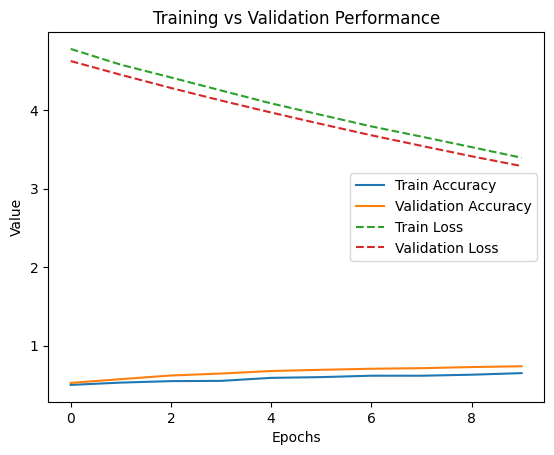

In [78]:
plt.figure()
 
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'],     linestyle='--', label='Train Loss')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation Loss')
 
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training vs Validation Performance")
plt.legend()
plt.show()

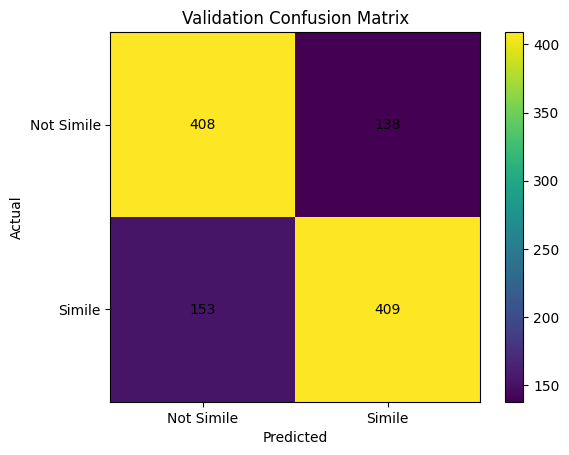

In [79]:
cm = confusion_matrix(y_val, y_val_pred)
 
plt.figure()
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.colorbar()
 
classes    = ["Not Simile", "Simile"]
tick_marks = np.arange(len(classes))
 
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
 
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
 
plt.show()

In [80]:
def explain_prediction(sentence):
 
    print("=" * 60)
    print("Sentence:")
    print(sentence)
 
    # Symbolic analysis
    symbolic_result = symbolic_detector(sentence)
    sym_features    = build_symbolic_matrix([sentence])
 
    # Preprocess
    ids, mask = PreprocessTexts([sentence])
 
    # Predict — use predict_both for full breakdown
    final_prob, bert_prob = model.predict_both(
        [ids, mask, sym_features]
    )
 
    final_prob     = float(final_prob[0][0])
    bert_prob      = float(bert_prob[0][0])
    symbolic_score = float(sym_features[0][0] * sym_features[0][2])
    prediction     = "Simile" if final_prob > 0.5 else "Not Simile"
 
    # Symbolic layer
    print("\n[Symbolic Layer]")
 
    if symbolic_result.structures:
        for s in symbolic_result.structures:
            print("\nRule:", s.rule)
            print("المشبه:", s.subject)
            print("الأداة:", s.particle)
            print("المشبه به:", s.object)
            print("Rule Confidence:", round(s.confidence, 3))
    else:
        print("No symbolic structure detected")
 
    # Neural layer
    print("\n[AraBERT Layer]")
    print("AraBERT Confidence:", round(bert_prob, 3))
 
    # Hybrid decision
    print("\n[Hybrid Decision]")
    print("Symbolic Score:",     round(symbolic_score, 3))
    print("Final Hybrid Score:", round(final_prob, 3))
    print("Prediction:", prediction)
    print("=" * 60)

In [ ]:
explain_prediction("الرجل كالأسد في الشجاعة")
explain_prediction("السماء صافية اليوم")

Sentence:
الرجل كالأسد في الشجاعة

[Symbolic Layer]

Rule: prefix_simile
المشبه: None
الأداة: كـ
المشبه به: الأسد
Rule Confidence: 0.676

[AraBERT Layer]
AraBERT Confidence: 0.399

[Hybrid Decision]
Symbolic Score: 0.55
Final Hybrid Score: 0.442
Prediction: Not Simile
Sentence:
السماء صافية اليوم

[Symbolic Layer]
No symbolic structure detected

[AraBERT Layer]
AraBERT Confidence: 0.195

[Hybrid Decision]
Symbolic Score: 0.0
Final Hybrid Score: 0.286
Prediction: Not Simile
Sentence:
قلبها كالحجارة في القسوة

[Symbolic Layer]

Rule: prefix_simile
المشبه: None
الأداة: كـ
المشبه به: الحجارة
Rule Confidence: 0.676

[AraBERT Layer]
AraBERT Confidence: 0.306

[Hybrid Decision]
Symbolic Score: 0.55
Final Hybrid Score: 0.377
Prediction: Not Simile
Sentence:
ذهب الطالب إلى المدرسة

[Symbolic Layer]
No symbolic structure detected

[AraBERT Layer]
AraBERT Confidence: 0.385

[Hybrid Decision]
Symbolic Score: 0.0
Final Hybrid Score: 0.418
Prediction: Not Simile


In [82]:
explain_prediction("قلبها كالحجارة في القسوة")
explain_prediction("ذهب الطالب إلى المدرسة")

Sentence:
قلبها كالحجارة في القسوة

[Symbolic Layer]

Rule: prefix_simile
المشبه: None
الأداة: كـ
المشبه به: الحجارة
Rule Confidence: 0.676

[AraBERT Layer]
AraBERT Confidence: 0.306

[Hybrid Decision]
Symbolic Score: 0.55
Final Hybrid Score: 0.377
Prediction: Not Simile
Sentence:
ذهب الطالب إلى المدرسة

[Symbolic Layer]
No symbolic structure detected

[AraBERT Layer]
AraBERT Confidence: 0.385

[Hybrid Decision]
Symbolic Score: 0.0
Final Hybrid Score: 0.418
Prediction: Not Simile
